# Real-Data Eigen Diagnostics — Pure-Space Smooth Sweep

실제 July GEMS data를 사용해서 pure-space isotropic Matérn model을 fit하고,
각 fitted covariance의 eigenbasis whitening diagnostic을 비교한다.

Fit smooth sweep:
- `smooth=0.3` — spline Matérn
- `smooth=0.5` — exponential Matérn

Reference runner:
`Exercises/st_model/day/real_data/eda/eig_diag_real_july_pure_space.py`

기본은 `RUN_NOW = False`라서 notebook을 열어도 무거운 fitting은 바로 실행되지 않는다.

Notes:
- plot titles and summary tables report `D` only as a diagnostic statistic.
- no Brownian-bridge significance number is reported, because it is not exact after fitting.
- eigen index means fitted covariance eigenvalue rank (`lambda_1 >= ... >= lambda_m`), not necessarily spatial frequency. Early indices are large fitted-variance eigenmodes.


In [8]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/private/tmp/matplotlib')

import sys
import shlex
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('/Users/joonwonlee/Documents/GEMS_TCO-1')
REAL_SCRIPT = ROOT / 'Exercises/st_model/day/real_data/eda/eig_diag_real_july_pure_space.py'
assert REAL_SCRIPT.exists(), REAL_SCRIPT

src_path = str(ROOT / 'src')
old_pythonpath = os.environ.get('PYTHONPATH', '')
if src_path not in old_pythonpath.split(os.pathsep):
    os.environ['PYTHONPATH'] = src_path + (os.pathsep + old_pythonpath if old_pythonpath else '')

try:
    display
except NameError:
    def display(obj):
        if hasattr(obj, 'to_string'):
            print(obj.to_string())
        else:
            print(obj)

print('REAL_SCRIPT =', REAL_SCRIPT)


REAL_SCRIPT = /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/real_data/eda/eig_diag_real_july_pure_space.py


## Configuration

Default input is 2022 July real data, matching the 2022 smooth=0.5 simulation diagnostic setup.

기본 좌표는 `Source_Latitude`, `Source_Longitude`이다. 이것은 real source location 기반 fitting이다.
regular grid 좌표로 fitting하고 싶으면 `Y_COL='Latitude'`, `X_COL='Longitude'`로 바꾸면 된다.


In [9]:
RUN_NOW = True

In [10]:
YEAR = 2022
MONTH = 7
DAYS = '1,1'       # first pass: July 1 only. Use '1,31' for full July.
HOURS = 'first'    # 'first', 'all', slot list/range such as '0,3,6'
HOUR_MATCH = 'slot'
SMOOTHS = [0.3, 0.5]
VARIANTS = ['nugget0', 'nugget_free']  # compare fixed-zero nugget and estimated nugget fits

REGIONS = 'tiles4x4,sparse'
TILE_Y, TILE_X = 4, 4
SPARSE_STRIDES = '8,4'

NEIGHBORS = 8
MEAN_DESIGN = 'base'
LBFGS_STEPS = 8
LBFGS_EVAL = 20
TARGET_CHUNK_SIZE = 1024
MIN_POINTS = 80
MAX_POINTS = 0
COV_JITTER = 1e-8

# Real source-location coordinates by default.
X_COL = 'Source_Longitude'
Y_COL = 'Source_Latitude'
VALUE_COL = 'ColumnAmountO3'
COORDS = 'raw'      # 'raw' degree units, or 'lonlat' local km transform

DEVICE = 'auto'
EIG_DEVICE = 'same'
CUDA_FALLBACK = 'cpu'


candidate_inputs = [
    Path(f'/Users/joonwonlee/Documents/GEMS_DATA/pickle_{YEAR}/tco_grid_{str(YEAR)[-2:]}_07.pkl'),
    Path(f'/Users/joonwonlee/Documents/GEMS_DATA/pickle_{YEAR}/tco_grid_lat-3to7_lon111to131_{str(YEAR)[-2:]}_07.pkl'),
]
INPUT_PICKLE = next((p for p in candidate_inputs if p.exists()), None)
OUT_ROOT = ROOT / f'outputs/day/local_eigen_analysis/eigdiag_real_july{YEAR}_fit_smooth_sweep_051926'
OUT_ROOT.mkdir(parents=True, exist_ok=True)

print('INPUT_PICKLE =', INPUT_PICKLE)
if INPUT_PICKLE is None:
    print('WARNING: real July pickle not found. Set INPUT_PICKLE manually.')
print('OUT_ROOT =', OUT_ROOT)
print('coords columns =', Y_COL, X_COL)


INPUT_PICKLE = /Users/joonwonlee/Documents/GEMS_DATA/pickle_2022/tco_grid_22_07.pkl
OUT_ROOT = /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/local_eigen_analysis/eigdiag_real_july2022_fit_smooth_sweep_051926
coords columns = Source_Latitude Source_Longitude


In [11]:
if INPUT_PICKLE is not None:
    obj = pd.read_pickle(INPUT_PICKLE)
    print(type(obj), 'n_hours=', len(obj) if hasattr(obj, '__len__') else None)
    if isinstance(obj, dict):
        first_key = sorted(obj.keys())[0]
        first_df = obj[first_key]
        print('first key:', first_key, 'shape:', first_df.shape)
        print('columns:', list(first_df.columns))
        display(first_df[[c for c in [Y_COL, X_COL, VALUE_COL, 'Latitude', 'Longitude'] if c in first_df.columns]].head())


<class 'dict'> n_hours= 240
first key: y22m07day01_hm00:53 shape: (18126, 6)
columns: ['Latitude', 'Longitude', 'ColumnAmountO3', 'Hours_elapsed', 'Source_Latitude', 'Source_Longitude']


,Source_Latitude,Source_Longitude,ColumnAmountO3,Latitude,Longitude
0,1.993286,130.98509,245.46179,2.0,131.000
1,1.993518,130.92276,248.36003,2.0,130.937
2,1.993755,130.86070,244.51955,2.0,130.874
3,1.993883,130.79854,245.17859,2.0,130.811
4,1.994068,130.73639,246.54607,2.0,130.748


## Build commands

Each smooth value runs the same real-data eigen diagnostic script and writes outputs under
`OUT_ROOT/nu0p3`, `OUT_ROOT/nu0p5`, and `OUT_ROOT/nu1`.


In [12]:
def smooth_tag(smooth):
    return str(float(smooth)).rstrip('0').rstrip('.').replace('.', 'p')


def build_real_cmd(smooth):
    if INPUT_PICKLE is None:
        raise FileNotFoundError('Set INPUT_PICKLE before building commands.')
    return [
        sys.executable, str(REAL_SCRIPT),
        '--input', str(INPUT_PICKLE),
        '--output-root', str(OUT_ROOT),
        '--year', str(YEAR),
        '--month', str(MONTH),
        '--days', str(DAYS),
        '--hours', str(HOURS),
        '--hour-match', str(HOUR_MATCH),
        '--smooth', str(float(smooth)),
        '--regions', REGIONS,
        '--tile-y', str(TILE_Y),
        '--tile-x', str(TILE_X),
        '--sparse-strides', SPARSE_STRIDES,
        '--variants', ','.join(VARIANTS),
        '--neighbors', str(NEIGHBORS),
        '--mean-design', MEAN_DESIGN,
        '--x-col', X_COL,
        '--y-col', Y_COL,
        '--value-col', VALUE_COL,
        '--coords', COORDS,
        '--device', DEVICE,
        '--eig-device', EIG_DEVICE,
        '--cuda-fallback', CUDA_FALLBACK,
        '--target-chunk-size', str(TARGET_CHUNK_SIZE),
        '--lbfgs-steps', str(LBFGS_STEPS),
        '--lbfgs-eval', str(LBFGS_EVAL),
        '--min-points', str(MIN_POINTS),
        '--max-points', str(MAX_POINTS),
        '--cov-jitter', str(COV_JITTER),
    ]

commands = {smooth: build_real_cmd(smooth) for smooth in SMOOTHS} if INPUT_PICKLE is not None else {}
for smooth, cmd in commands.items():
    print('\n# smooth', smooth)
    print(' '.join(shlex.quote(x) for x in cmd))



# smooth 0.3
/opt/anaconda3/envs/faiss_env/bin/python /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/real_data/eda/eig_diag_real_july_pure_space.py --input /Users/joonwonlee/Documents/GEMS_DATA/pickle_2022/tco_grid_22_07.pkl --output-root /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/local_eigen_analysis/eigdiag_real_july2022_fit_smooth_sweep_051926 --year 2022 --month 7 --days 1,1 --hours first --hour-match slot --smooth 0.3 --regions tiles4x4,sparse --tile-y 4 --tile-x 4 --sparse-strides 8,4 --variants nugget0,nugget_free --neighbors 8 --mean-design base --x-col Source_Longitude --y-col Source_Latitude --value-col ColumnAmountO3 --coords raw --device auto --eig-device same --cuda-fallback cpu --target-chunk-size 1024 --lbfgs-steps 8 --lbfgs-eval 20 --min-points 80 --max-points 0 --cov-jitter 1e-08

# smooth 0.5
/opt/anaconda3/envs/faiss_env/bin/python /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/real_data/eda/eig_diag_real_july_pure_space.py --in

In [ ]:
if RUN_NOW:
    for smooth in SMOOTHS:
        print('\n' + '=' * 78)
        print('Running real-data eigen diagnostic, smooth =', smooth)
        print('=' * 78)
        subprocess.run(build_real_cmd(smooth), check=True)
else:
    print('RUN_NOW is False. Set RUN_NOW=True to run fitting/eigen diagnostics.')



Running real-data eigen diagnostic, smooth = 0.3
CUDA not available; using CPU.
REAL DATA: input=/Users/joonwonlee/Documents/GEMS_DATA/pickle_2022/tco_grid_22_07.pkl
fit_device=cpu, eig_device=cpu, selected_hours=1, smooth=0.3

[real 20220701 h0053] key=y22m07day01_hm00:53, rows=18126
  tile_r1c1_of_4x4: n=1143
Pre-computing HybridSpaceVecchia [A=8]... Done in 0.0s. tails=1143, m mean/med/max=8.0/8/8
--- Starting Pure-Space Vecchia L-BFGS ---
--- Step 1/8 / Loss: 1.094147 / Max Grad: 6.80e-08 ---
Converged: max_grad 6.80e-08 < 1.00e-05
Final Pure-Space Params: {'sigmasq': 3.255959282828215, 'range': 0.03994404000349943, 'nugget': 0.0}
    nugget0: sigmasq=3.256, range=0.03994, nugget=0, D=2.053, saved nugget0_tile_r1c1_of_4x4_eigdiag.png
Pre-computing HybridSpaceVecchia [A=8]... Done in 0.0s. tails=1143, m mean/med/max=8.0/8/8
--- Starting Pure-Space Vecchia L-BFGS ---
--- Step 1/8 / Loss: 1.132937 / Max Grad: 5.66e-06 ---
Converged: max_grad 5.66e-06 < 1.00e-05
Final Pure-Space Param

## Combine summaries after running


summary files found: 2 / 2
OK    /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/local_eigen_analysis/eigdiag_real_july2022_fit_smooth_sweep_051926/nu0p3/real_eigen_diagnostic_summary.csv
OK    /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/local_eigen_analysis/eigdiag_real_july2022_fit_smooth_sweep_051926/nu0p5/real_eigen_diagnostic_summary.csv


,data_type,day,hour,minute,hour_key,family,unit,unit_label,variant,smooth,...,n_obs,mean_rank,n_eigen,eigen_threshold,min_kept_eigen,max_kept_eigen,sum_y2,mean_y2,max_abs_bridge_scaled,brown_bridge_width
0,real,20220701,0,53,y22m07day01_hm00:53,tiles4x4,tile_r1c1_of_4x4,"tile row 1/4, col 1/4",nugget0,0.3,...,1143,2,1141,0.0,1.616967,12.841383,1138.051301,0.997416,2.052563,64.876895
1,real,20220701,0,53,y22m07day01_hm00:53,tiles4x4,tile_r1c2_of_4x4,"tile row 1/4, col 2/4",nugget0,0.3,...,1147,2,1145,0.0,1.496619,4.074028,1146.066800,1.000932,1.269877,64.990514
2,real,20220701,0,53,y22m07day01_hm00:53,tiles4x4,tile_r1c3_of_4x4,"tile row 1/4, col 3/4",nugget0,0.3,...,1126,2,1124,0.0,1.311005,11.557368,1124.159289,1.000142,0.733879,64.391774
3,real,20220701,0,53,y22m07day01_hm00:53,tiles4x4,tile_r1c4_of_4x4,"tile row 1/4, col 4/4",nugget0,0.3,...,1133,2,1131,0.0,1.766271,911.797498,1132.092751,1.000966,0.985823,64.591971
4,real,20220701,0,53,y22m07day01_hm00:53,tiles4x4,tile_r2c1_of_4x4,"tile row 2/4, col 1/4",nugget0,0.3,...,1119,2,1117,0.0,1.532827,20.536165,1115.486312,0.998645,1.384924,64.190952


Saved combined summary: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/local_eigen_analysis/eigdiag_real_july2022_fit_smooth_sweep_051926/real_eigen_diagnostic_summary_all_smooths.csv
Saved tile D summary: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/local_eigen_analysis/eigdiag_real_july2022_fit_smooth_sweep_051926/real_tile_eigen_diagnostic_summary_all_smooths.csv


,day,hour,minute,hour_key,variant,smooth,unit,unit_label,n_obs,n_eigen,max_abs_bridge_scaled,sum_y2,mean_y2,sigmasq,range,nugget,loss
0,20220701,0,53,y22m07day01_hm00:53,nugget0,0.3,tile_r1c1_of_4x4,"tile row 1/4, col 1/4",1143,1141,2.052563,1138.051301,0.997416,3.255959,0.039944,0.0,1.094147
1,20220701,0,53,y22m07day01_hm00:53,nugget0,0.3,tile_r1c2_of_4x4,"tile row 1/4, col 2/4",1147,1145,1.269877,1146.066800,1.000932,2.059029,0.025017,0.0,0.997450
2,20220701,0,53,y22m07day01_hm00:53,nugget0,0.3,tile_r1c3_of_4x4,"tile row 1/4, col 3/4",1126,1124,0.733879,1124.159289,1.000142,2.666846,0.042017,0.0,1.024448
3,20220701,0,53,y22m07day01_hm00:53,nugget0,0.3,tile_r1c4_of_4x4,"tile row 1/4, col 4/4",1133,1131,0.985823,1132.092751,1.000966,11.417449,0.289313,0.0,1.207600
4,20220701,0,53,y22m07day01_hm00:53,nugget0,0.3,tile_r2c1_of_4x4,"tile row 2/4, col 1/4",1119,1117,1.384924,1115.486312,0.998645,3.509918,0.050698,0.0,1.089078
5,20220701,0,53,y22m07day01_hm00:53,nugget0,0.3,tile_r2c2_of_4x4,"tile row 2/4, col 2/4",1092,1090,1.107840,1090.670196,1.000615,2.819533,0.027654,0.0,1.084161
6,20220701,0,53,y22m07day01_hm00:53,nugget0,0.3,tile_r2c3_of_4x4,"tile row 2/4, col 3/4",1142,1140,3.181813,1132.818847,0.993701,2.760885,0.047724,0.0,1.021094
7,20220701,0,53,y22m07day01_hm00:53,nugget0,0.3,tile_r2c4_of_4x4,"tile row 2/4, col 4/4",1116,1114,1.555697,1110.272841,0.996654,4.696246,0.107397,0.0,1.071222
8,20220701,0,53,y22m07day01_hm00:53,nugget0,0.3,tile_r3c1_of_4x4,"tile row 3/4, col 1/4",1119,1117,1.647684,1117.409770,1.000367,2.690358,0.024369,0.0,1.077540
9,20220701,0,53,y22m07day01_hm00:53,nugget0,0.3,tile_r3c2_of_4x4,"tile row 3/4, col 2/4",1109,1107,1.136539,1106.968439,0.999971,3.370232,0.032039,0.0,1.130331


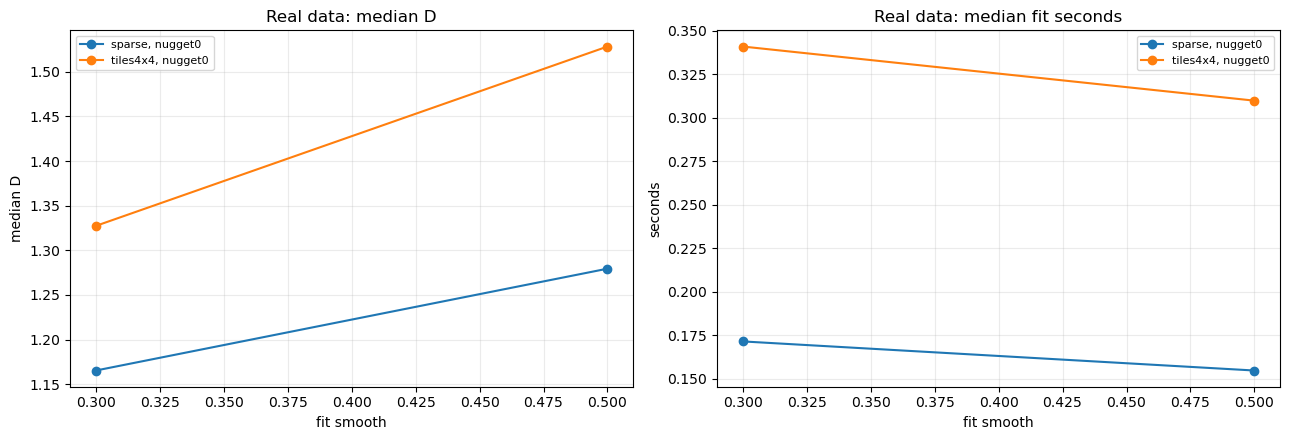

In [ ]:
summary_paths = [OUT_ROOT / f'nu{smooth_tag(s)}' / 'real_eigen_diagnostic_summary.csv' for s in SMOOTHS]
existing = [p for p in summary_paths if p.exists()]
print('summary files found:', len(existing), '/', len(summary_paths))
for p in summary_paths:
    print(('OK   ' if p.exists() else 'MISS '), p)

if existing:
    summary_df = pd.concat([pd.read_csv(p) for p in existing], ignore_index=True)
    old_sig_col = 'brown_' + 'bridge_' + 'p' + 'value_approx'
    summary_df = summary_df.drop(columns=[old_sig_col], errors='ignore')
    display(summary_df.head())

    combined_path = OUT_ROOT / 'real_eigen_diagnostic_summary_all_smooths.csv'
    summary_df.to_csv(combined_path, index=False, float_format='%.6f')
    print('Saved combined summary:', combined_path)

    tile_df = summary_df[summary_df['family'].eq('tiles4x4')].copy()
    if not tile_df.empty:
        tile_cols = [
            'day', 'hour', 'minute', 'hour_key', 'variant', 'smooth', 'unit', 'unit_label',
            'n_obs', 'n_eigen', 'max_abs_bridge_scaled', 'sum_y2', 'mean_y2',
            'sigmasq', 'range', 'nugget', 'loss',
        ]
        tile_cols = [c for c in tile_cols if c in tile_df.columns]
        tile_path = OUT_ROOT / 'real_tile_eigen_diagnostic_summary_all_smooths.csv'
        tile_df[tile_cols].to_csv(tile_path, index=False, float_format='%.6f')
        print('Saved tile D summary:', tile_path)
        display(tile_df[tile_cols].sort_values(['smooth', 'variant', 'unit']).head(32))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for (family, variant), sub in summary_df.groupby(['family', 'variant']):
        by = sub.groupby('smooth')['max_abs_bridge_scaled'].median()
        axes[0].plot(by.index, by.values, 'o-', label=f'{family}, {variant}')
    axes[0].set_title('Real data: median D')
    axes[0].set_xlabel('fit smooth')
    axes[0].set_ylabel('median D')
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=8)

    for (family, variant), sub in summary_df.groupby(['family', 'variant']):
        by = sub.groupby('smooth')['fit_seconds'].median()
        axes[1].plot(by.index, by.values, 'o-', label=f'{family}, {variant}')
    axes[1].set_title('Real data: median fit seconds')
    axes[1].set_xlabel('fit smooth')
    axes[1].set_ylabel('seconds')
    axes[1].grid(alpha=0.25)
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    fig.savefig(OUT_ROOT / 'real_smooth_sweep_summary_051926.png', dpi=160, bbox_inches='tight')
    plt.show()
else:
    print('No summary yet. Run the fitting cells first.')


## Eigen Plot Gallery

저장된 eigen diagnostic PNG를 notebook 안에서 바로 확인한다. `RUN_NOW=True`로 fitting을 돌린 뒤 이 셀을 실행하면 `tiles4x4` overview와 `x4/x8` sparse plot이 표시된다.


### nugget0: tiles4x4 overview (3 found)

**outputs/day/local_eigen_analysis/eigdiag_real_july2022_fit_smooth_sweep_051926/nu0p3/20220701_h0053/nugget0_tiles4x4_overview.png**

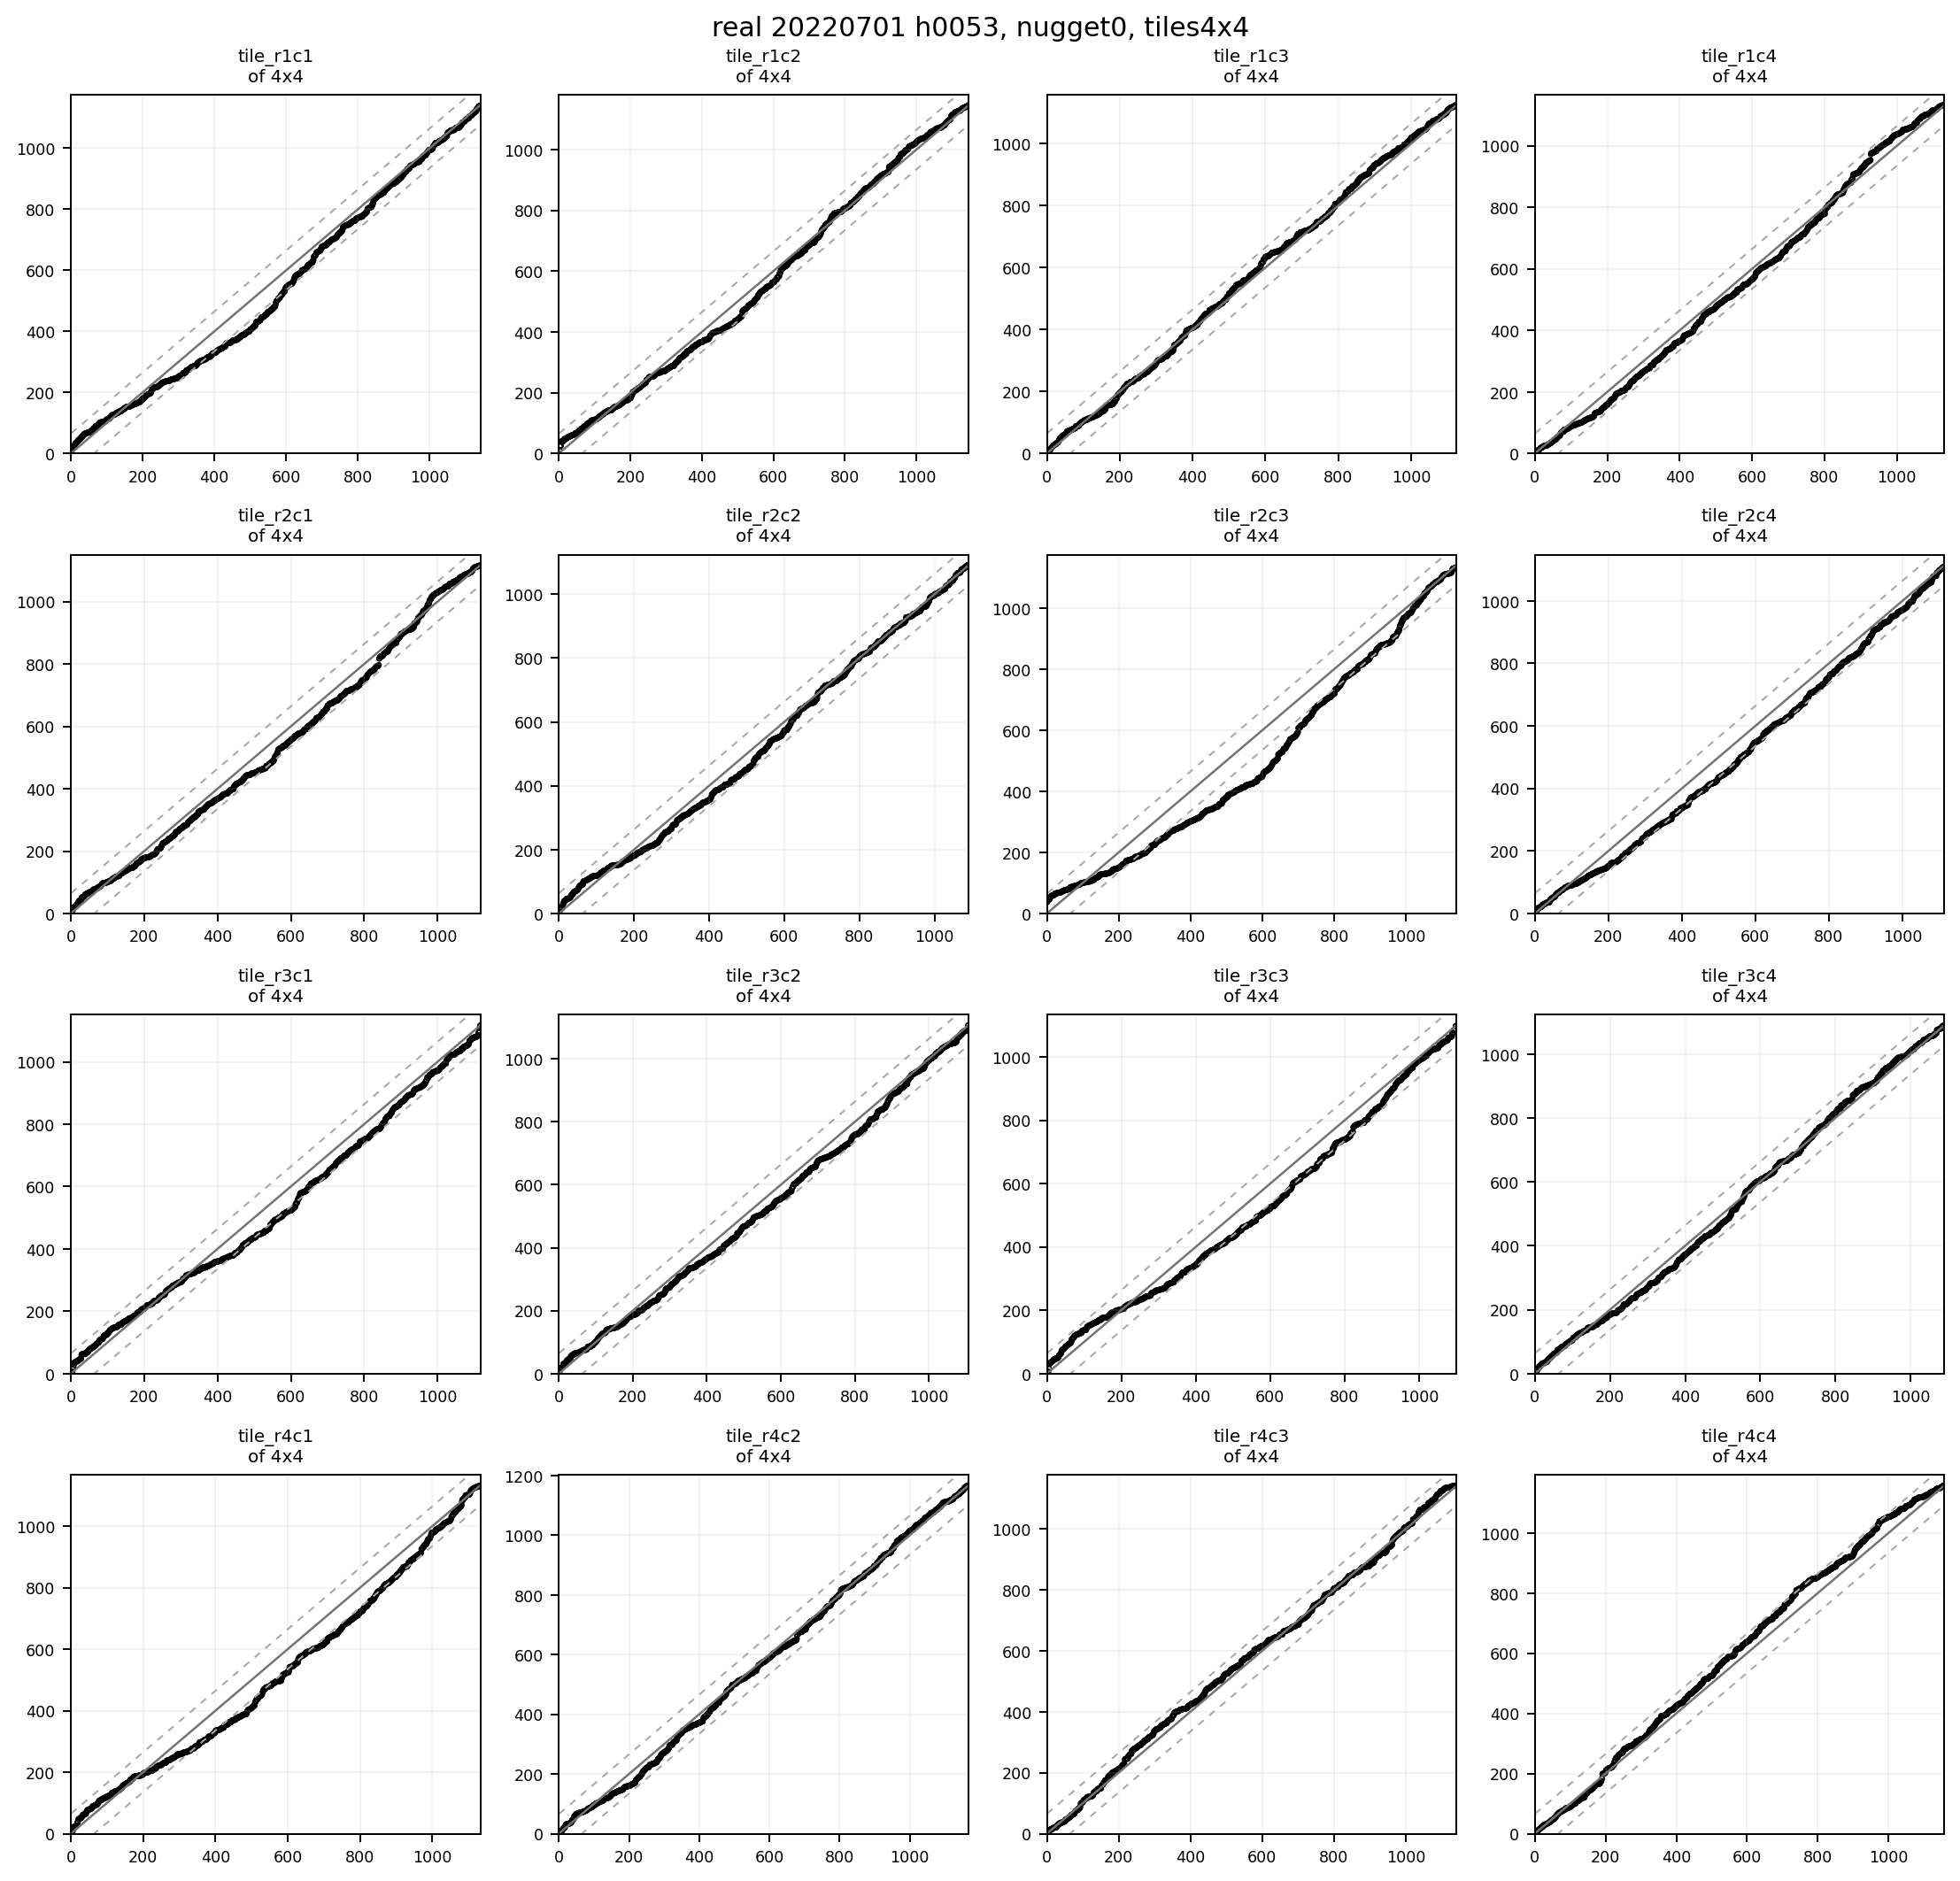

**outputs/day/local_eigen_analysis/eigdiag_real_july2022_fit_smooth_sweep_051926/nu0p5/20220701_h0053/nugget0_tiles4x4_overview.png**

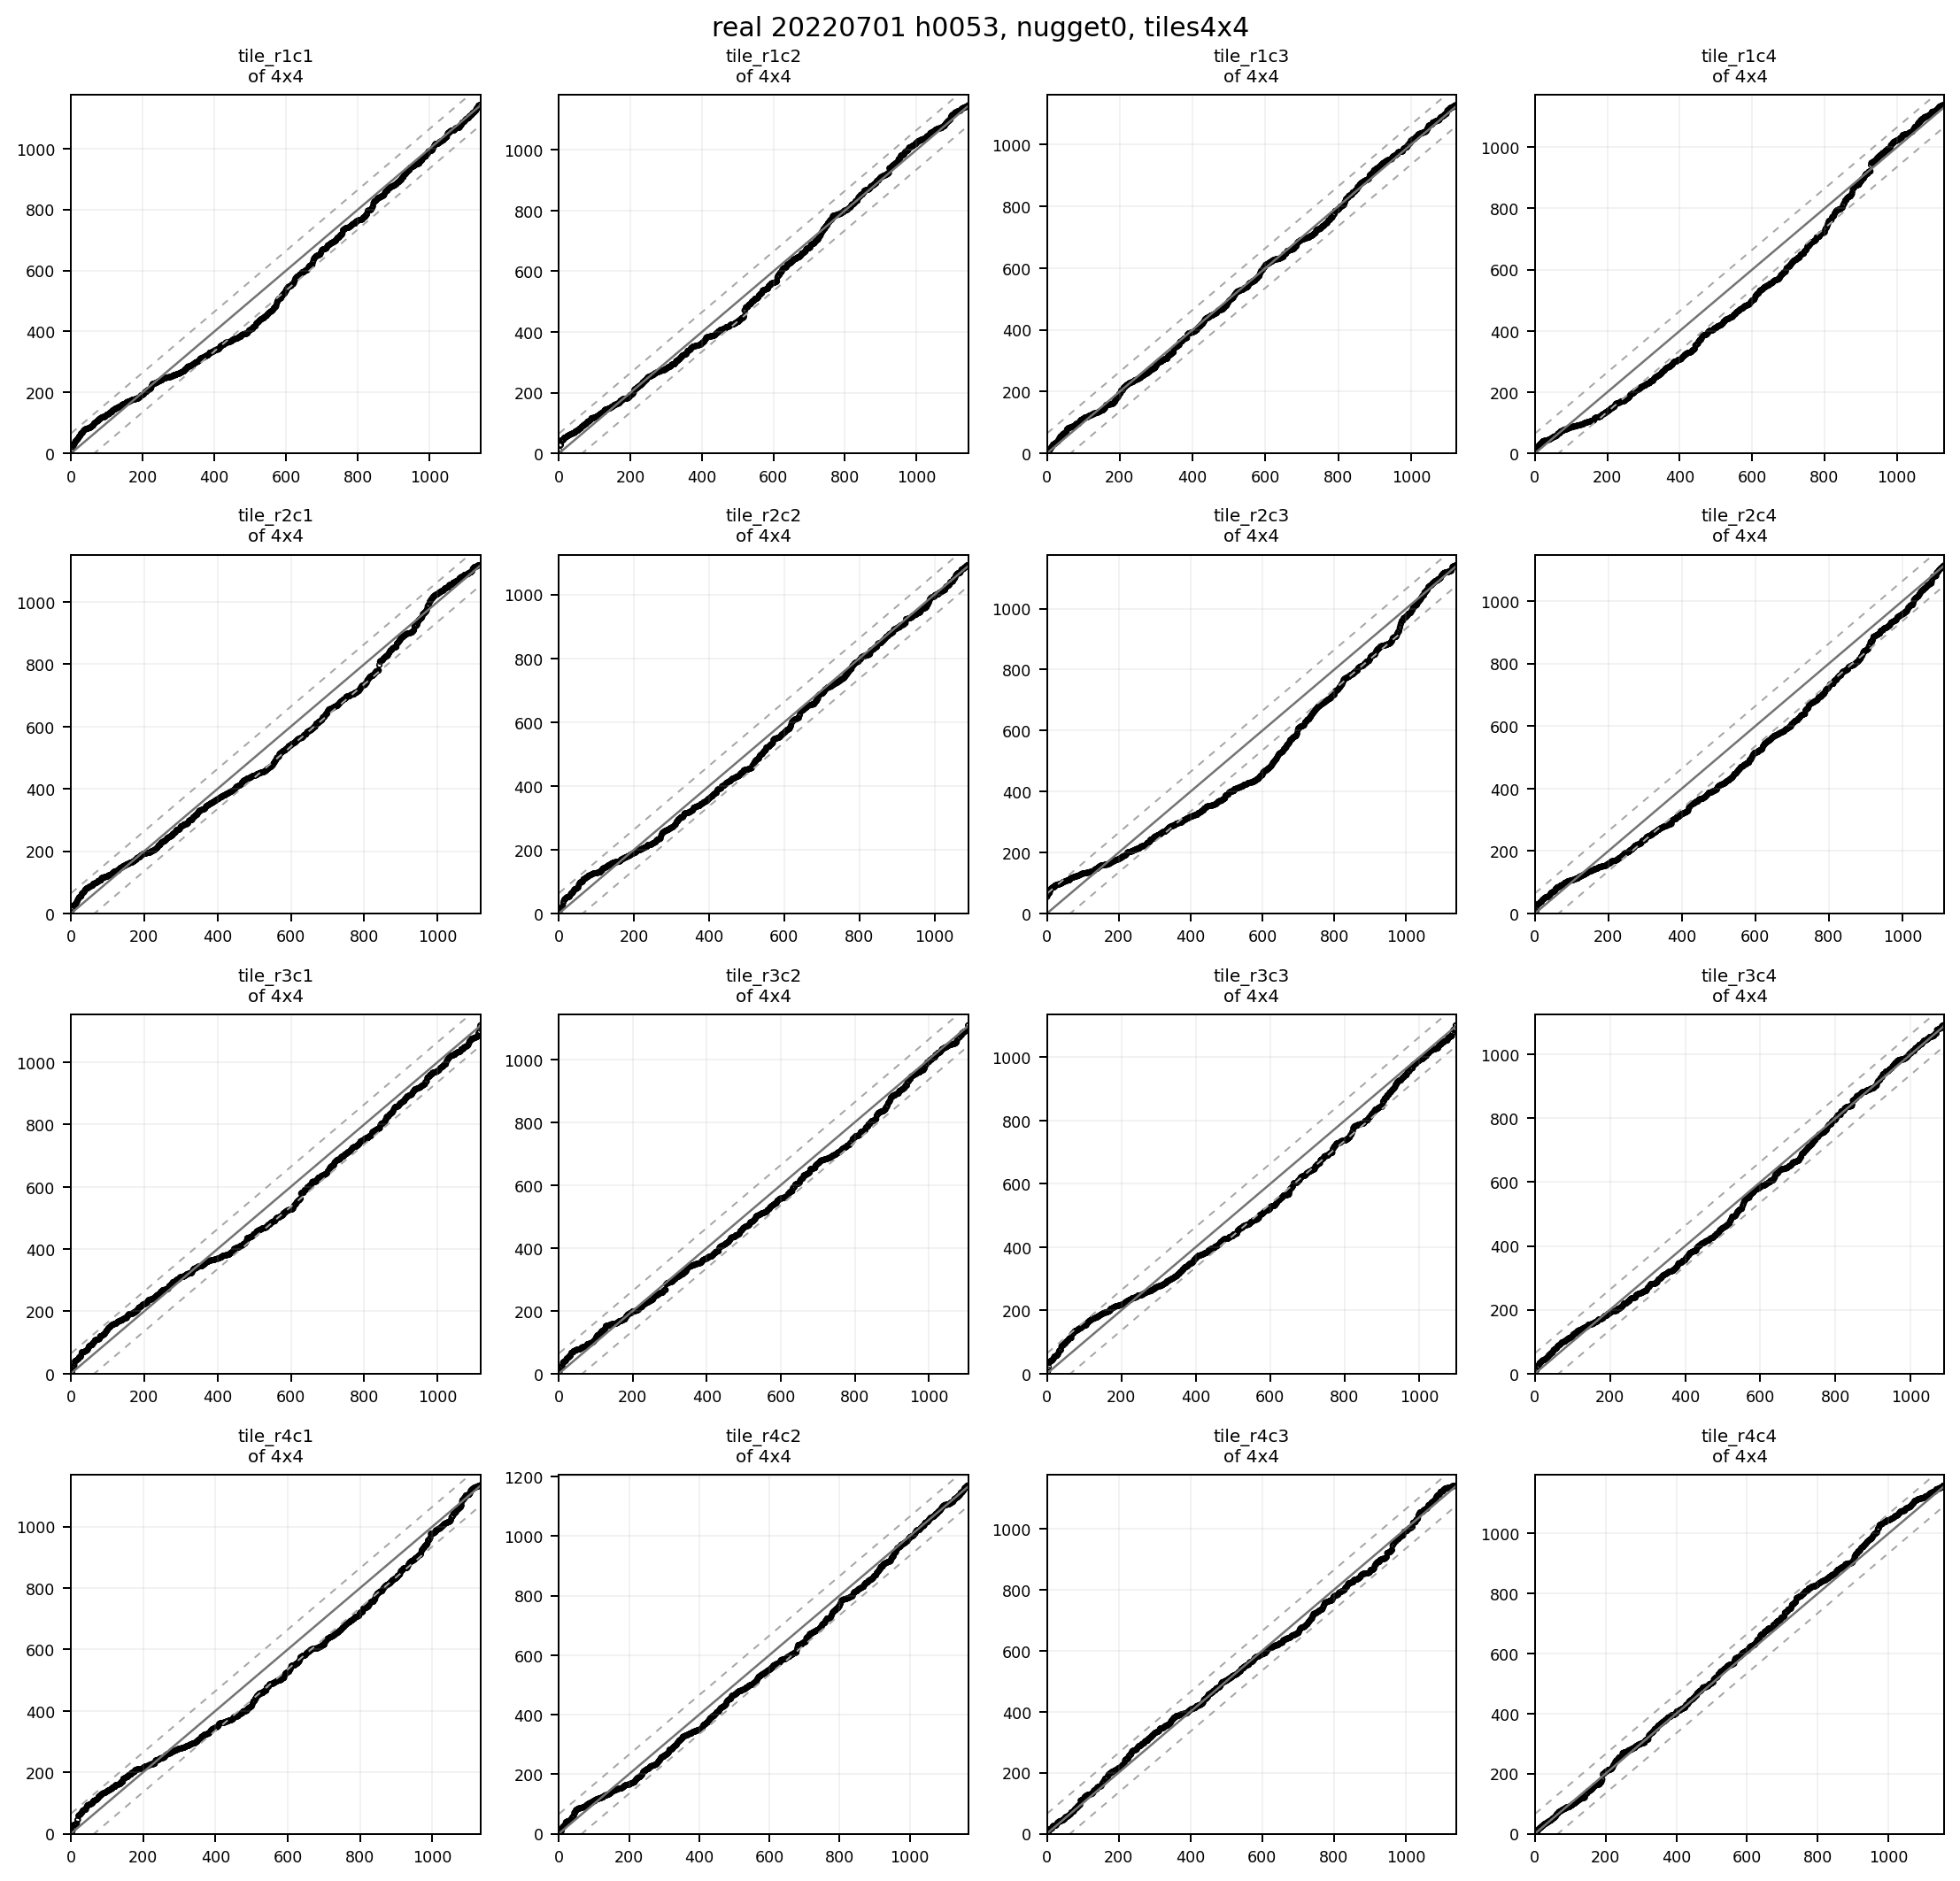

**outputs/day/local_eigen_analysis/eigdiag_real_july2022_fit_smooth_sweep_051926/nu1/20220701_h0053/nugget0_tiles4x4_overview.png**

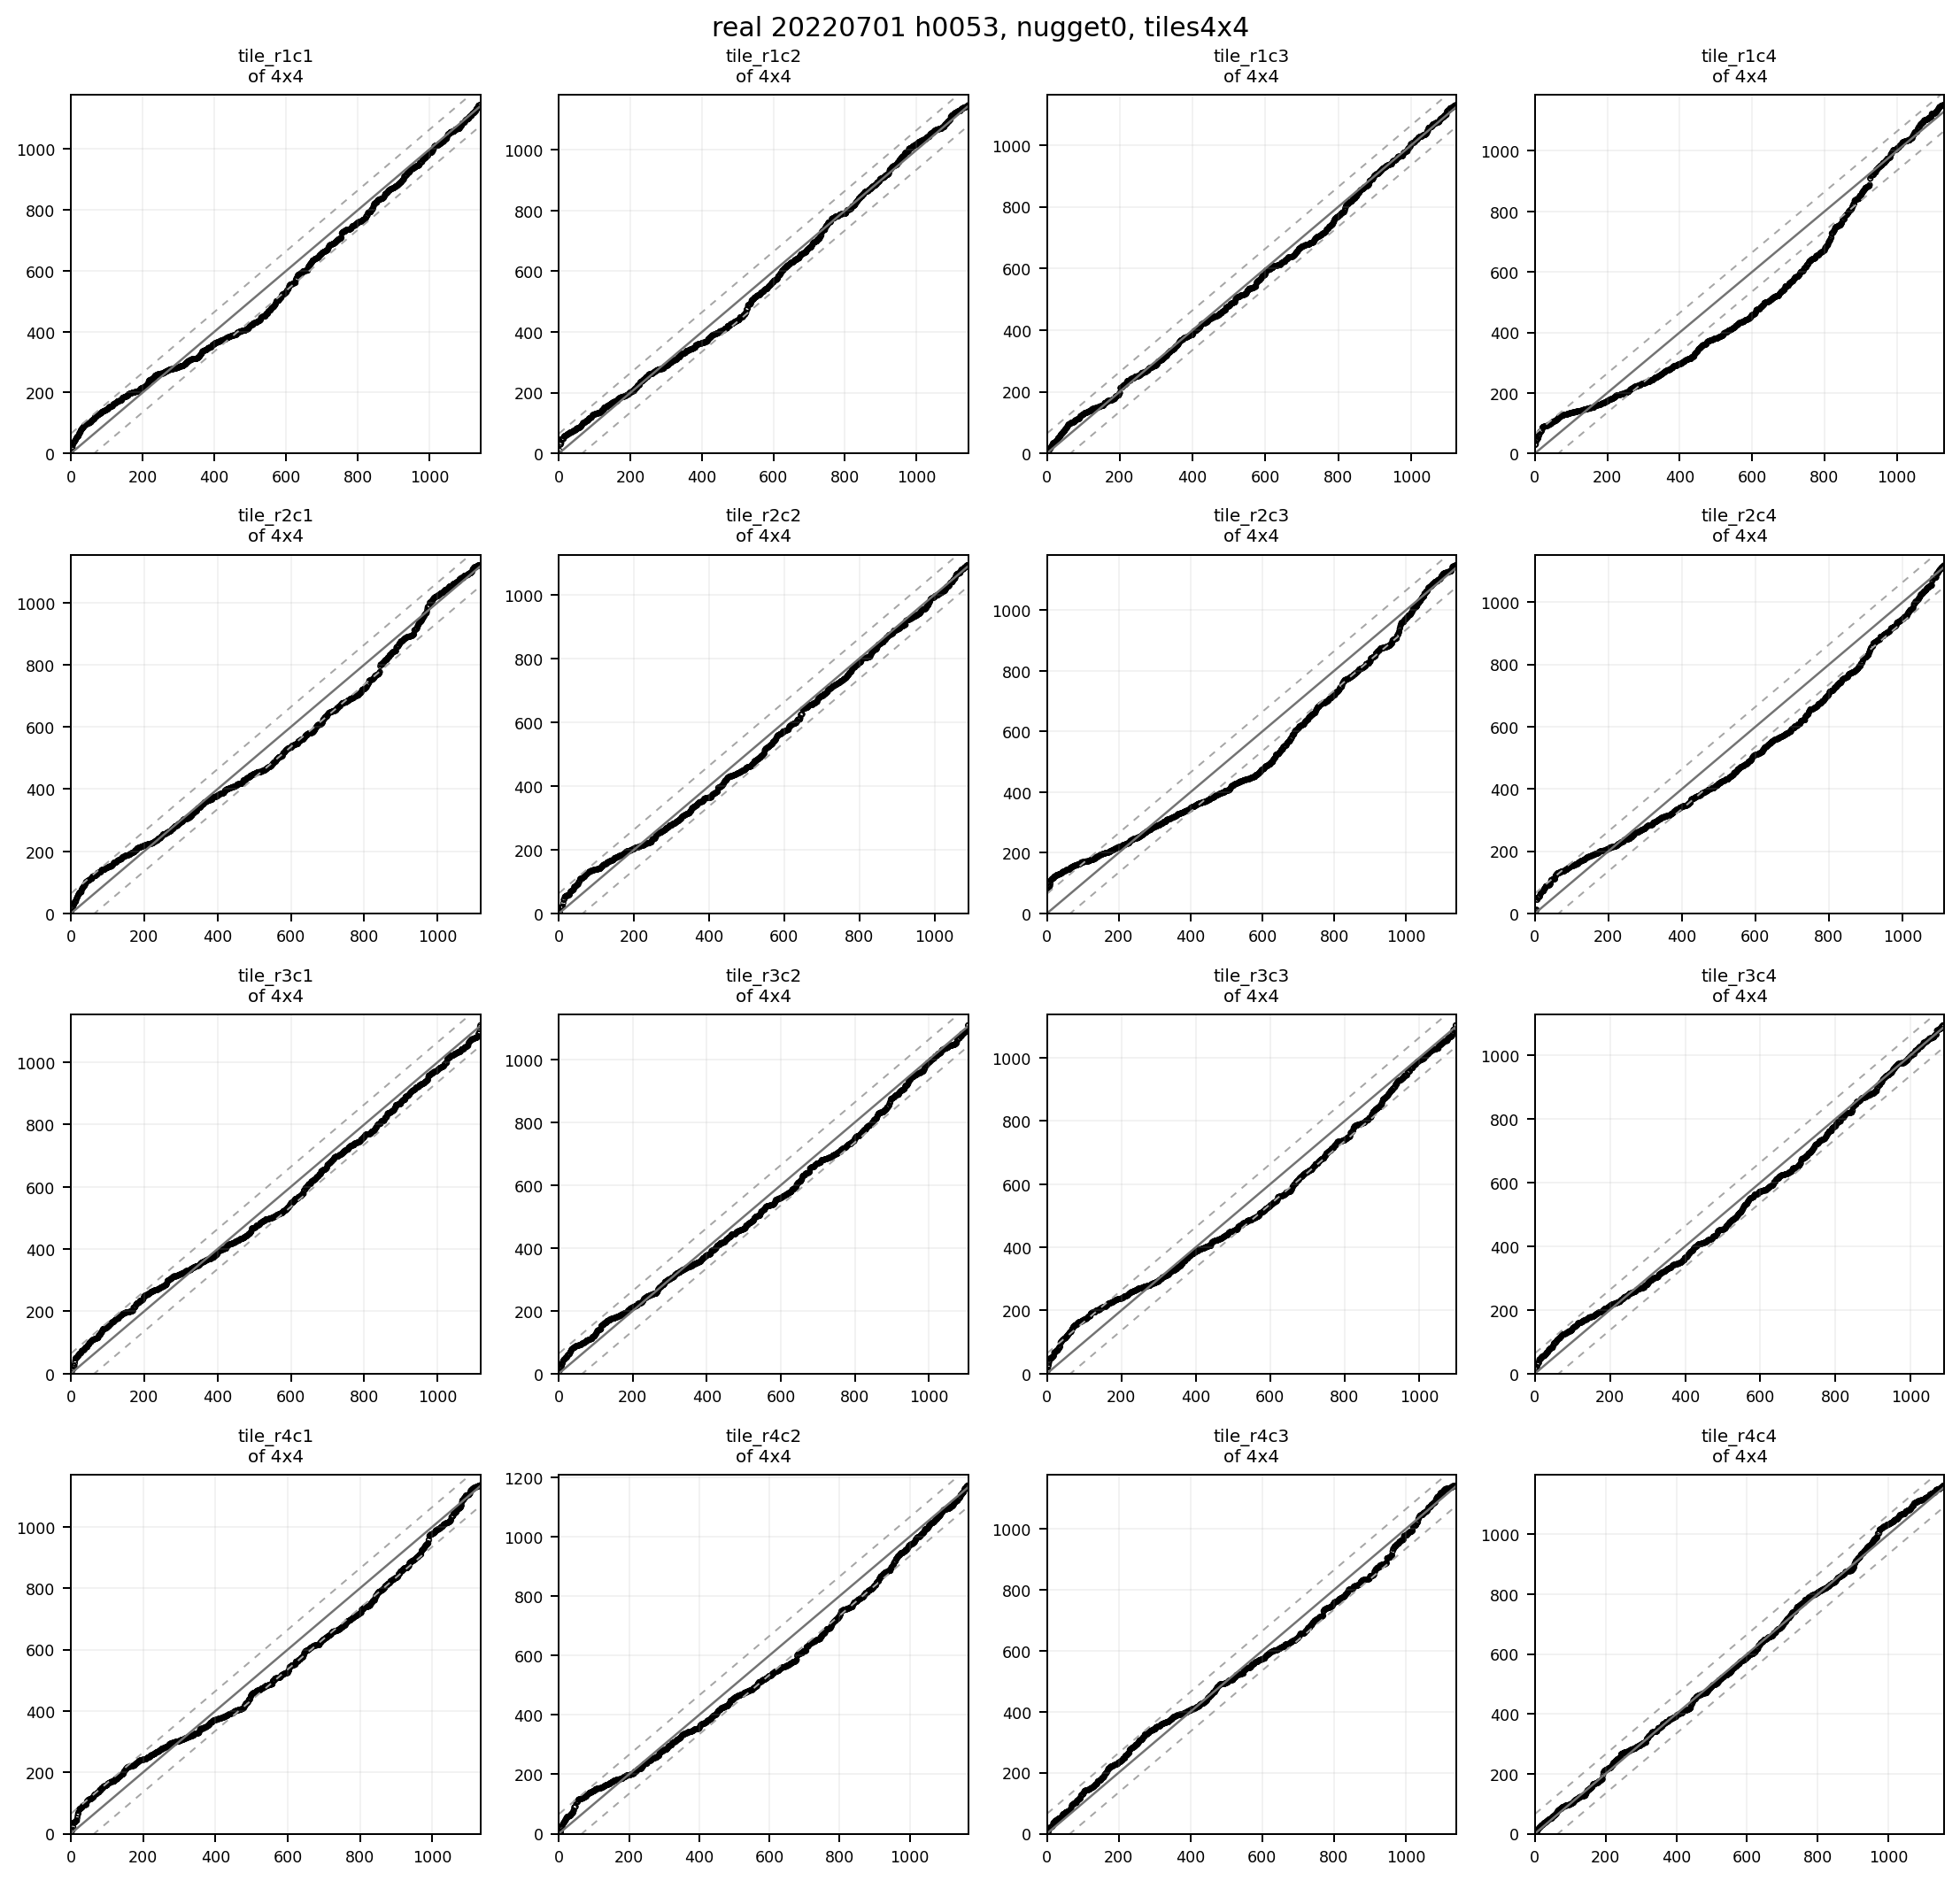

### nugget0: sparse x4 (3 found)

**outputs/day/local_eigen_analysis/eigdiag_real_july2022_fit_smooth_sweep_051926/nu0p3/20220701_h0053/nugget0_x4_eigdiag.png**

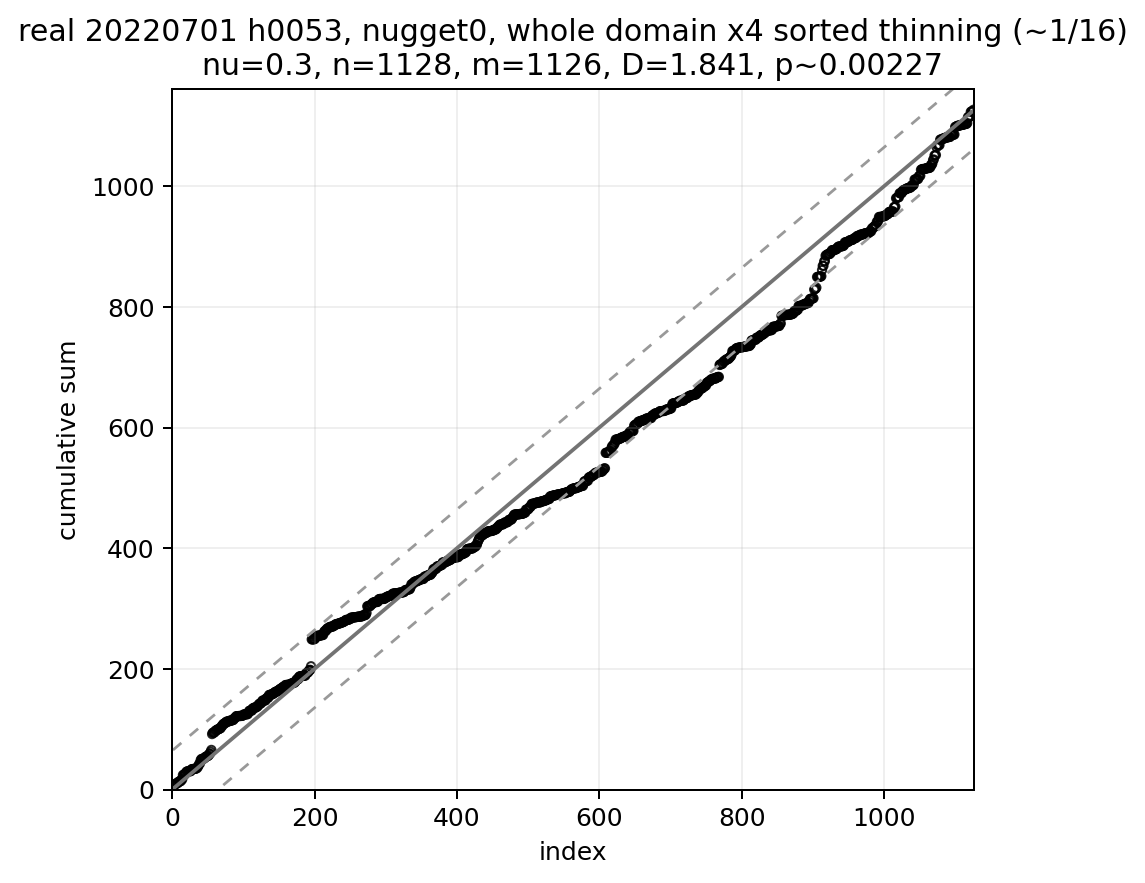

**outputs/day/local_eigen_analysis/eigdiag_real_july2022_fit_smooth_sweep_051926/nu0p5/20220701_h0053/nugget0_x4_eigdiag.png**

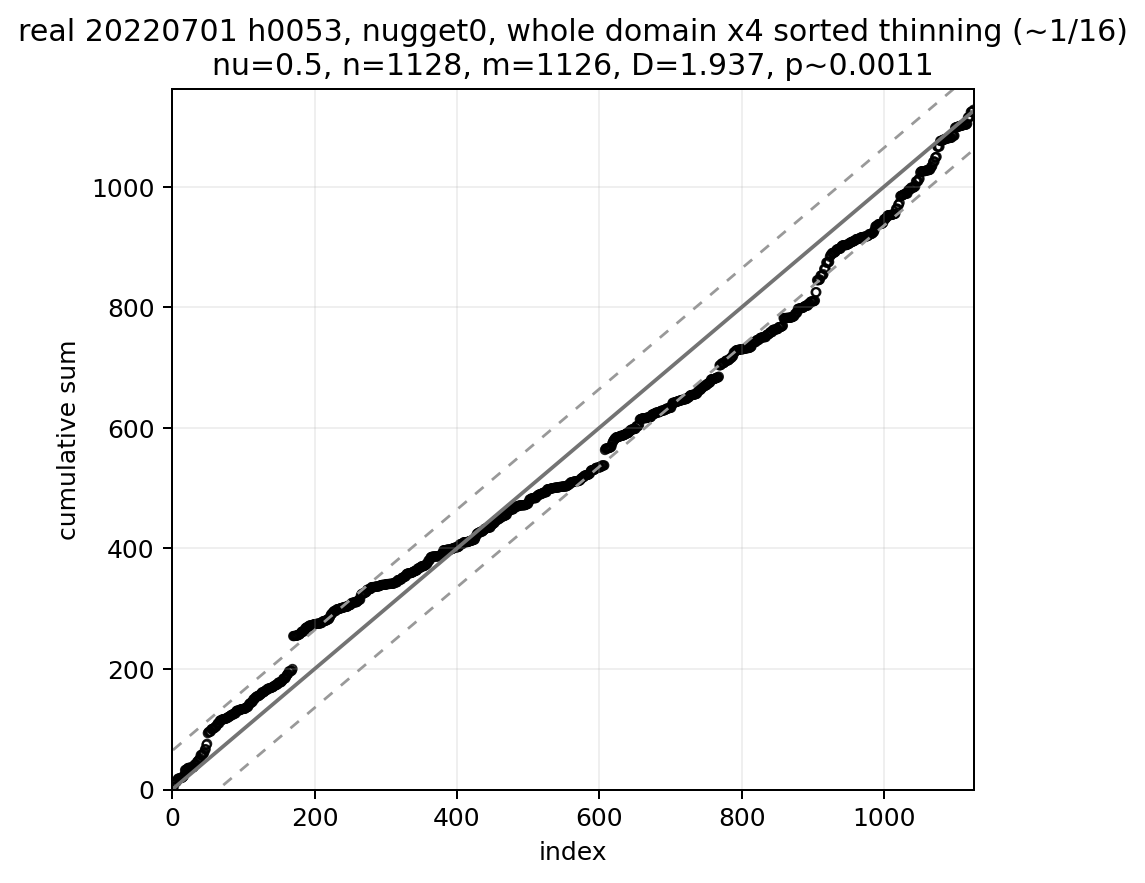

**outputs/day/local_eigen_analysis/eigdiag_real_july2022_fit_smooth_sweep_051926/nu1/20220701_h0053/nugget0_x4_eigdiag.png**

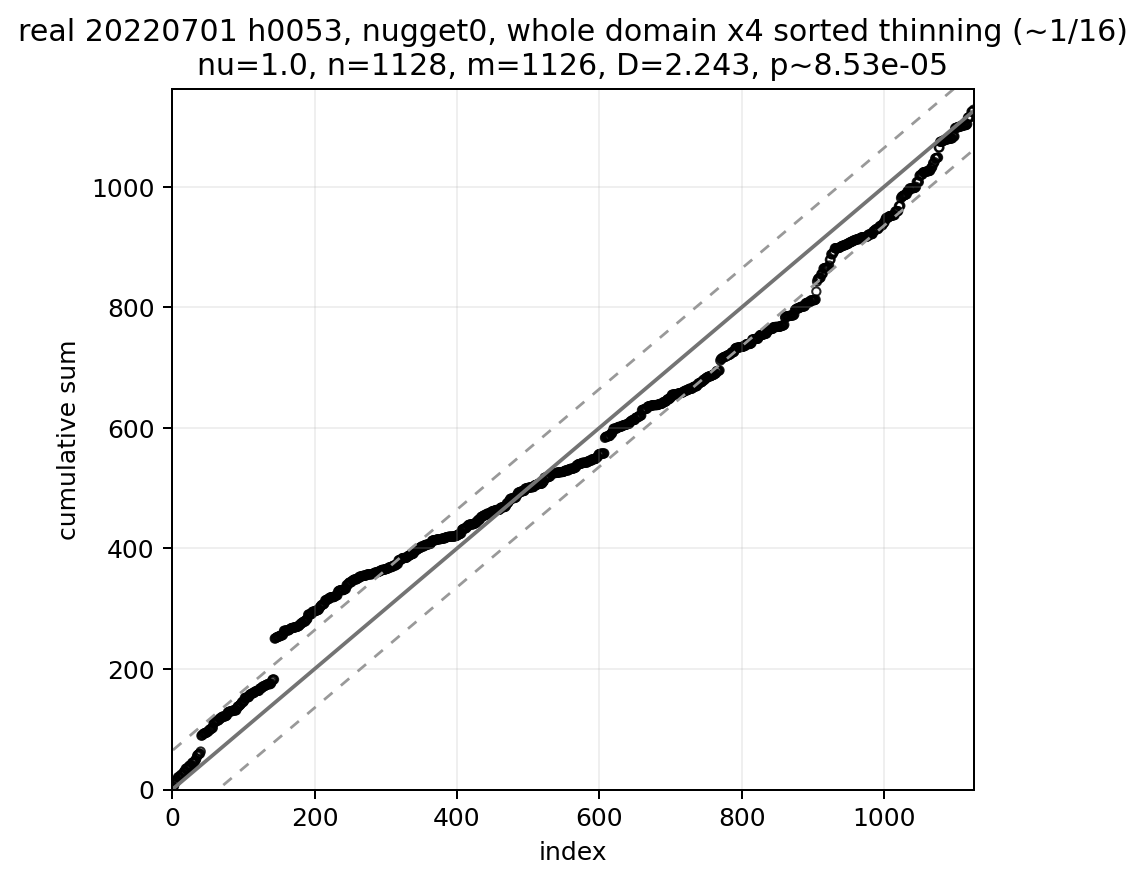

### nugget0: sparse x8 (3 found)

**outputs/day/local_eigen_analysis/eigdiag_real_july2022_fit_smooth_sweep_051926/nu0p3/20220701_h0053/nugget0_x8_eigdiag.png**

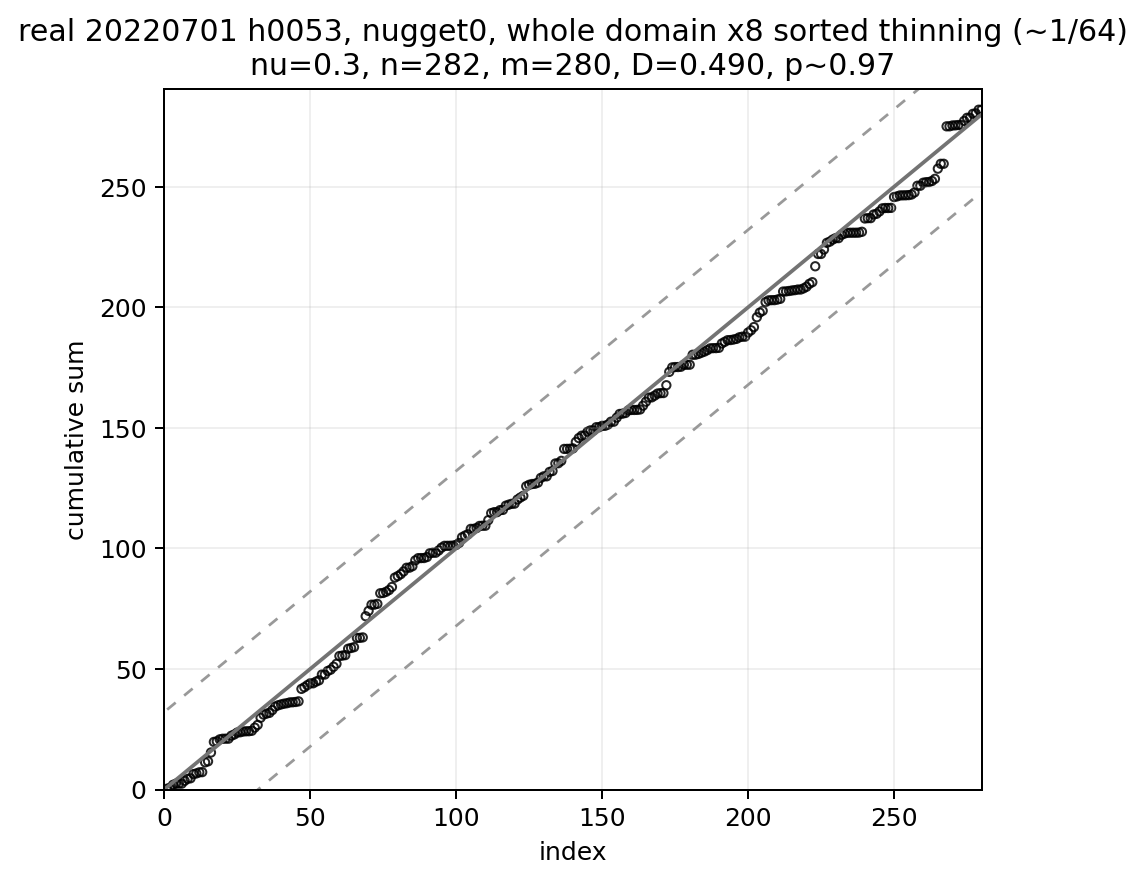

**outputs/day/local_eigen_analysis/eigdiag_real_july2022_fit_smooth_sweep_051926/nu0p5/20220701_h0053/nugget0_x8_eigdiag.png**

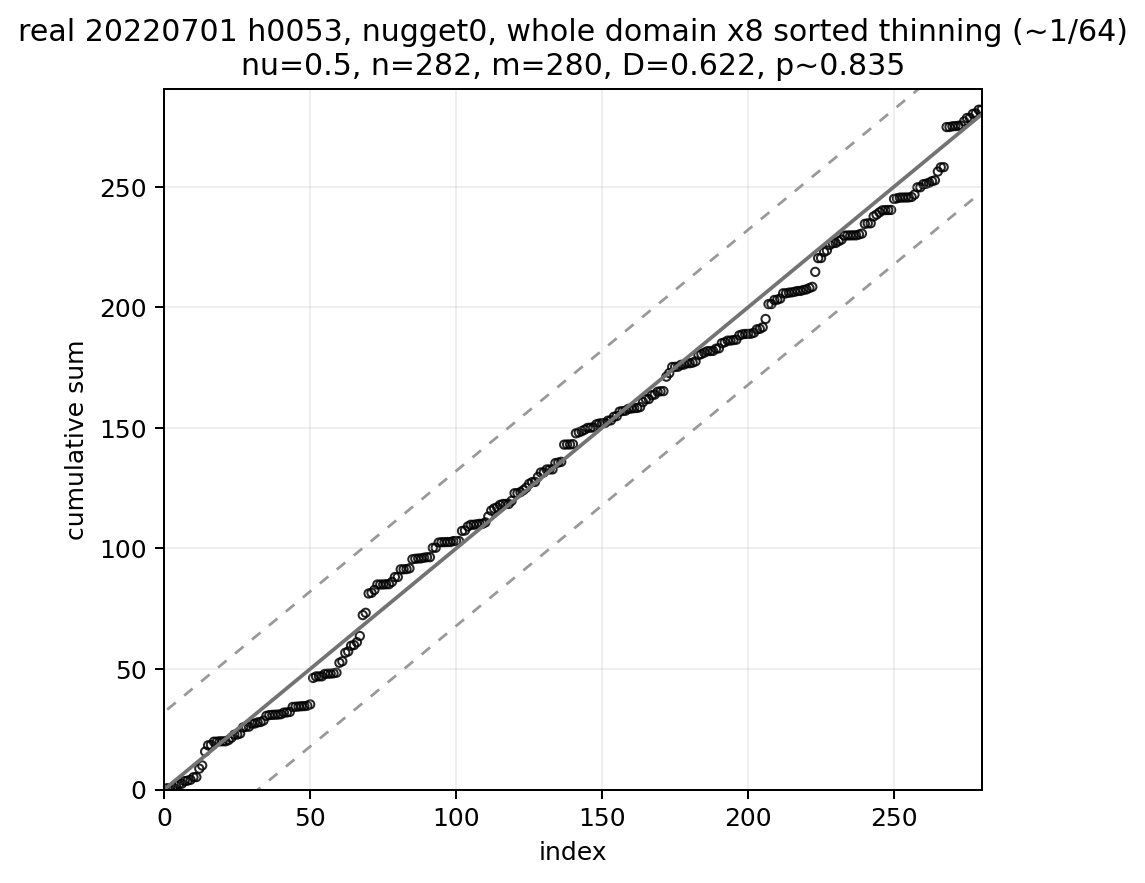

**outputs/day/local_eigen_analysis/eigdiag_real_july2022_fit_smooth_sweep_051926/nu1/20220701_h0053/nugget0_x8_eigdiag.png**

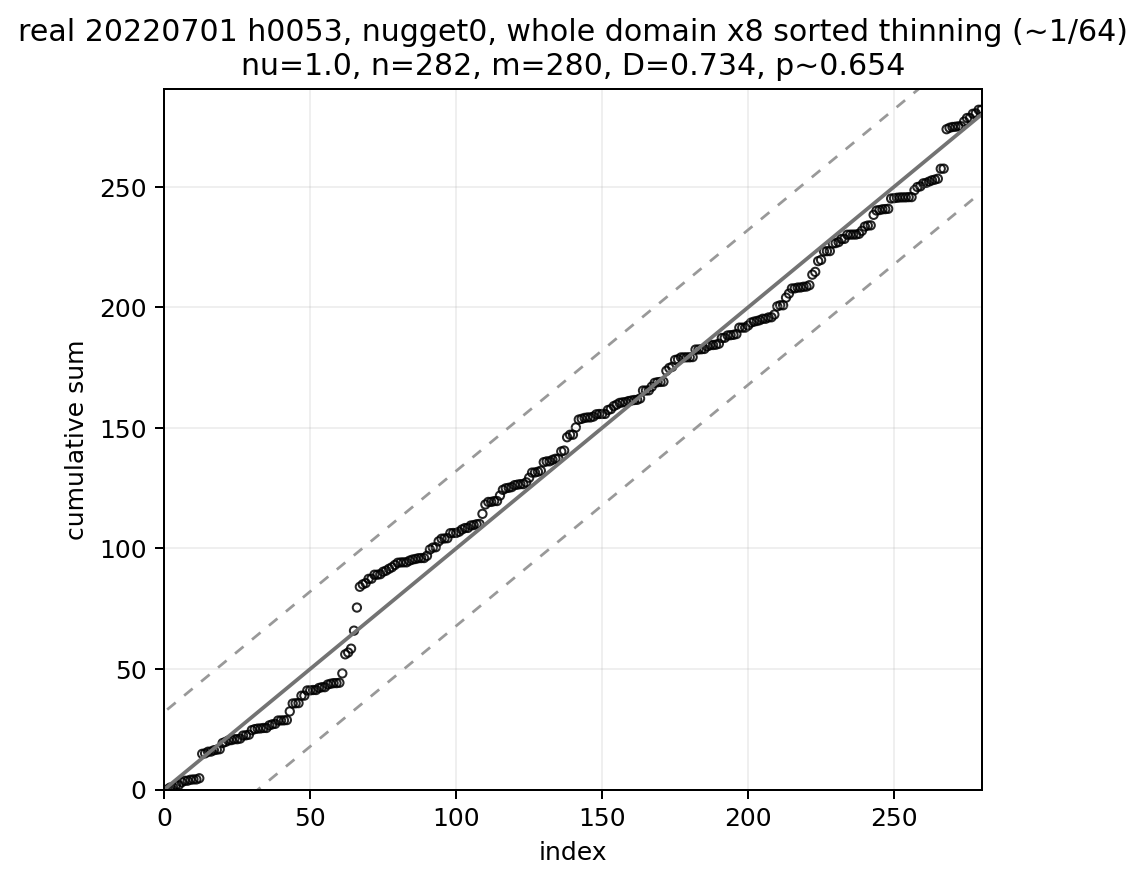

### nugget_free: tiles4x4 overview (0 found)

No files matching: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/local_eigen_analysis/eigdiag_real_july2022_fit_smooth_sweep_051926/nu*/20*_h*/nugget_free_tiles4x4_overview.png


### nugget_free: sparse x4 (0 found)

No files matching: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/local_eigen_analysis/eigdiag_real_july2022_fit_smooth_sweep_051926/nu*/20*_h*/nugget_free_x4_eigdiag.png


### nugget_free: sparse x8 (0 found)

No files matching: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/local_eigen_analysis/eigdiag_real_july2022_fit_smooth_sweep_051926/nu*/20*_h*/nugget_free_x8_eigdiag.png


In [ ]:
try:
    from IPython.display import Image, Markdown, display
except Exception:
    Image = None
    def Markdown(text):
        return text
    def display(obj):
        print(obj)


def _rel(path):
    path = Path(path)
    try:
        return path.relative_to(ROOT)
    except Exception:
        return path


def _display_png(path, width=1150):
    path = Path(path)
    display(Markdown(f"**{_rel(path)}**"))
    if Image is None:
        print(path)
    else:
        display(Image(filename=str(path), width=width))


def show_eigen_gallery(max_per_pattern=6):
    patterns = []
    for variant in VARIANTS:
        patterns.extend([
            (f'{variant}: tiles4x4 overview', f'nu*/20*_h*/{variant}_tiles4x4_overview.png', 1250),
            (f'{variant}: sparse x4', f'nu*/20*_h*/{variant}_x4_eigdiag.png', 760),
            (f'{variant}: sparse x8', f'nu*/20*_h*/{variant}_x8_eigdiag.png', 760),
        ])
    any_found = False
    for label, pattern, width in patterns:
        matches = sorted(Path(OUT_ROOT).glob(pattern))
        display(Markdown(f"### {label} ({len(matches)} found)"))
        if not matches:
            print(f"No files matching: {OUT_ROOT / pattern}")
            continue
        any_found = True
        for path in matches[:max_per_pattern]:
            _display_png(path, width=width)
        if len(matches) > max_per_pattern:
            print(f"... {len(matches) - max_per_pattern} more files not shown")
    if not any_found:
        print('No eigen PNGs found yet. Run the fitting cell first, or check OUT_ROOT.')

show_eigen_gallery(max_per_pattern=9)
